# Reusable notebook analysis framework

This notebook demonstrates a reusable pattern for locating repository data, summarizing metrics, and running business-level analysis such as trend checks, conversion rates, and cross-tab comparisons.

   source  total_visits
0     ads         38934
1  search         34273
2  social         31396
3   email         29879


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29376\319666138.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


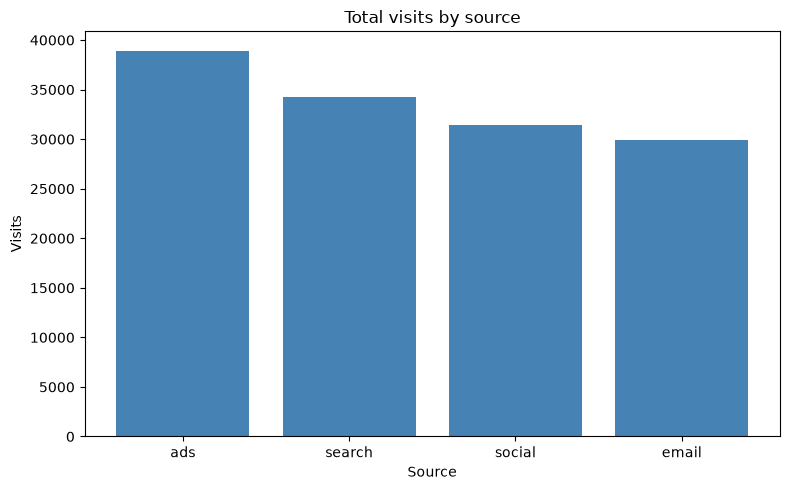

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent.parent
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from notebook_framework import (
    NotebookProject,
    conversion_rate_by,
    crosstab_summary,
    moving_average,
    period_over_period_growth,
    plot_summary,
    summarize_by,
    time_series_summary,
    trend_regression,
)

project = NotebookProject(REPO_ROOT)
df = project.load_csv("notebook_env_demo.csv")

summary = summarize_by(df, group_by="source", value_col="visits")
print(summary.head())

figure, axis = plot_summary(
    summary,
    "source",
    "total_visits",
    title="Total visits by source",
    xlabel="Source",
    ylabel="Visits",
)
figure.show()

In [2]:
from pathlib import Path

import pandas as pd

from notebook_framework import (
    NotebookProject,
    conversion_rate_by,
    crosstab_summary,
    moving_average,
    period_over_period_growth,
    time_series_summary,
    trend_regression,
)

project = NotebookProject(Path.cwd().resolve().parent.parent)
df = project.load_csv("notebook_env_demo.csv")
df["date"] = pd.to_datetime(df["date"])

ts = time_series_summary(df, date_col="date", value_col="visits")
trend = trend_regression(df, x_col="date", y_col="visits")
rolling = moving_average(df, date_col="date", value_col="visits", window=7)
growth = period_over_period_growth(df, date_col="date", value_col="visits", periods=7)
by_channel = conversion_rate_by(df, group_by="source", visits_col="visits", orders_col="orders")
cross = crosstab_summary(
    df,
    index_col="source",
    columns_col="region",
    values_col="visits",
    aggfunc="sum",
)

print(ts.head())
print(trend["slope"], trend["r2"])
print(rolling[["date", "visits", "rolling_visits_7d"]].head())
print(growth[["date", "total_visits", "growth_rate"]].head())
print(by_channel.head())
print(cross.head())

        date  total_visits
0 2026-01-01          3167
1 2026-01-02          3011
2 2026-01-03          3602
3 2026-01-04          4357
4 2026-01-05          4019
18.538820912124553 0.4567373326194817
        date  visits  rolling_visits_7d
0 2026-01-01     836         836.000000
1 2026-01-01     924         880.000000
2 2026-01-01     731         830.333333
3 2026-01-01     676         791.750000
4 2026-01-02     786         790.600000


KeyError: "['total_visits'] not in index"